# ENCS5342 — Final Course Project (Track 1)
## Part-of-Speech Tagging on the English Penn Treebank

**Team:** Ahmad Zuhd (1222332), Bara Mohsen (1220829)  
**Track:** 1 — Default Project (POS Tagging)

---
### Individual Contribution Statement
- **Ahmad Zuhd:** BiLSTM + Char-CNN model, training loop, ablation experiments, and error analysis.
- **Bara Mohsen:** CoNLL parser, HMM/Viterbi baseline, evaluation metrics, and notebook write-up.

# 1. Abstract

We build and compare two Part-of-Speech taggers for English on the Penn Treebank
corpus, predicting a **joint coarse–fine tag** (for example, `NOUN-NNP`) for
every token. The first model is a bigram **Hidden Markov Model** decoded using
the **Viterbi** algorithm, while the second is a **bidirectional LSTM** with a
character-level CNN encoder, implemented and trained in PyTorch. We report
token-level accuracy together with per-class, micro-averaged, and macro-averaged
precision, recall, and F1-score on the training and development sets. The HMM
achieved **94.97% development accuracy** and **0.8288 macro-F1**, whereas the
full BiLSTM + Char-CNN model achieved the best development accuracy of
**97.43%** with **0.8649 macro-F1**. The ablation experiments show that removing
the character encoder or dropout reduces overall accuracy, although both
ablations produce slightly higher macro-F1 values in this single-seed run. The
error analysis therefore highlights both the strong performance on frequent
tags and the remaining instability on very rare tags.

# 2. Introduction

**Motivation.** POS tagging assigns a grammatical category to each word in
context. It is a foundational disambiguation problem: the same surface form can
take different tags depending on context (*"book a flight"* versus *"read a
book"*), and POS information supports parsing, named-entity recognition,
machine translation, and information-retrieval pipelines.

**Goals / research questions.**
1. How does a classical probabilistic tagger (HMM + Viterbi) compare with a
   neural sequence model on the joint-tag task?
2. How does a character-level encoder affect overall accuracy and performance
   on rare or unknown words?
3. What effect do dropout, gradient clipping, learning-rate scheduling, and
   early stopping have on development-set performance?

**Approach overview.** We parse the CoNLL data, build train-only vocabularies
with explicit `<UNK>` handling, implement both models, and evaluate them using a
metrics module that reports token accuracy and class-level, micro-averaged, and
macro-averaged precision, recall, and F1-score.

**Contributions.** Our work provides: (1) two taggers evaluated on a shared joint
label space; (2) a character-level word representation for handling spelling and
unknown-word information; (3) controlled ablation experiments for the character
encoder and dropout; and (4) an error analysis of the performance gap between
frequent and rare tags.

# 3. Prior & Related Work

POS tagging has a long history. **HMM taggers** with Viterbi decoding
(Kupiec, 1992) and discriminative **maximum-entropy** and dependency-based
taggers (Ratnaparkhi, 1996; Toutanova et al., 2003) defined much of the
classical approach to this task.

The neural shift introduced contextual sequence encoders. Most directly
relevant to our design, **Ma and Hovy (2016)** combine a character-level CNN, a
word-level bidirectional LSTM, and a CRF output layer for sequence labelling.
The character encoder captures spelling and morphological information, while
the BiLSTM represents left and right context.

**How our work relates and differs.** We use the BiLSTM + Char-CNN backbone of
Ma and Hovy on the **joint coarse–fine tag set**, but use a per-token softmax
classifier instead of a CRF. We also compare the neural architecture with a
bigram HMM baseline and use ablation experiments to measure the effect of the
character encoder and dropout under the same dataset split.

# 4. Model

## 4.1 HMM + Viterbi (baseline)
A bigram HMM models the joint probability of a tag sequence and word sequence as

$$P(t_{1:n}, w_{1:n}) = \prod_{i=1}^{n} P(t_i \mid t_{i-1})\, P(w_i \mid t_i)$$

We estimate transition $P(t_i\mid t_{i-1})$ and emission $P(w_i\mid t_i)$
probabilities by counting on the training set with **add-k smoothing**, and add
explicit `START` and `END` states. Decoding uses the **Viterbi** dynamic program
in log-space:

$$\delta_t(j) = \max_i \left[\delta_{t-1}(i) + \log P(t_j\mid t_i)\right] + \log P(w_t\mid t_j)$$

Unknown words rely on smoothed emissions, so their predictions are influenced
mainly by tag-transition context.

## 4.2 BiLSTM + Char-CNN (neural)
```
word  -> word embedding                                  ┐
chars -> char embedding -> 1D CNN -> max pooling         ┴-> concatenation -> BiLSTM -> Linear -> tag logits
```

The **character CNN** builds a representation from spelling patterns such as
prefixes, suffixes, and capitalization. This representation is designed to help
with rare and unknown words. The **BiLSTM** produces a context-aware
representation of every token using information from both directions, and a
linear layer produces the joint-tag logits.

The model is trained using masked cross-entropy while ignoring padding. The
training procedure uses dropout, embedding dropout, weight decay, gradient
clipping, early stopping based on development macro-F1, and learning-rate
scheduling. The reported experiments do **not** use pre-trained word
embeddings.

In [1]:
# ---- Imports, environment, and reproducibility ----
import sys
import os
import random
import platform
from pathlib import Path

# Add project src/ to the path whether the notebook is opened from the project
# root or from the notebooks/ folder.
for _p in ("src", "../src", os.path.join(os.getcwd(), "src")):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
        break

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from data import parse_conll, Vocab
from hmm import HMMTagger
from bilstm import BiLSTMTagger, ModelConfig
from train import train_model, TrainConfig, evaluate, set_seed
from metrics import (
    compute_metrics,
    metrics_summary,
    per_class_table,
    confusion_pairs,
    sklearn_crosscheck,
)

SEED = 42
set_seed(SEED)

# Extra deterministic settings for CUDA runs.
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

environment = pd.DataFrame([
    {"component": "Python", "version": platform.python_version()},
    {"component": "PyTorch", "version": torch.__version__},
    {"component": "NumPy", "version": np.__version__},
    {"component": "pandas", "version": pd.__version__},
    {"component": "scikit-learn", "version": sklearn.__version__},
    {"component": "Matplotlib", "version": matplotlib.__version__},
    {"component": "seaborn", "version": sns.__version__},
    {"component": "device", "version": DEVICE},
    {"component": "random seed", "version": str(SEED)},
])

print("Execution environment")
display(environment)


Execution environment


,component,version
0,Python,3.11.6
1,PyTorch,2.5.1+cpu
2,NumPy,2.4.4
3,pandas,3.0.2
4,scikit-learn,1.8.0
5,Matplotlib,3.10.8
6,seaborn,0.13.2
7,device,cpu
8,random seed,42


# 5. Data

**Source and format.** We use the English Penn Treebank corpus distributed in
Stanford-style CoNLL format. Each non-empty line represents one token. We use
column 2 as the word form, column 4 as the coarse POS tag, and column 5 as the
fine POS tag. The prediction target is the combined joint label
`coarse-fine`, such as `NOUN-NNP`.

**Splits.** The training set contains **37,840 sentences and 902,902 tokens**.
The development set contains **1,992 sentences and 47,126 tokens**. The
instructor keeps the test set hidden, so all model development and intermediate
reporting use only the provided training and development sets.

**Preprocessing.**
- The word, character, and tag vocabularies are constructed from the training
  set only, preventing development-set leakage.
- Words occurring fewer than two times are mapped to an explicit `<UNK>` token.
- Character sequences are retained for the Char-CNN representation.
- Variable-length sentences are padded during batching, and padding positions
  are excluded from the training loss and evaluation metrics.
- The final training vocabulary contains 23,099 word entries, 85 character
  entries, and 45 joint POS tags.

> Put `en-universal-train.conll` and `en-universal-dev.conll` in the project
> root before running the notebook.


In [2]:
TRAIN_PATH = "../en-universal-train.conll"
DEV_PATH   = "../en-universal-dev.conll"

train_data = parse_conll(TRAIN_PATH)
dev_data   = parse_conll(DEV_PATH)

vocab = Vocab.build(train_data, min_freq=2)

[parse_conll] ../en-universal-train.conll: 37840 sentences, 902902 tokens
[parse_conll] ../en-universal-dev.conll: 1992 sentences, 47126 tokens
[Vocab] words=23099 (min_freq=2) chars=85 tags=45


,split,sentences,tokens,mean_length,max_length,95th_percentile_length,unique_joint_tags
0,train,37840,902902,23.86,141,44.0,45
1,dev,1992,47126,23.66,79,44.0,45


Number of joint tags: 45
10 most frequent tags: [('NOUN-NN', 126176), ('ADP-IN', 102515), ('NOUN-NNP', 87033), ('DET-DT', 77723), ('ADJ-JJ', 58227), ('NOUN-NNS', 56900), ('.-,', 46317), ('.-.', 37506), ('NUM-CD', 34775), ('ADV-RB', 29382)]
10 rarest tags: [('.-(', 1308), ('DET-EX', 816), ('ADV-RBS', 436), ('DET-PDT', 353), ('X-FW', 228), ('PRON-WP$', 159), ('.-#', 138), ('X-UH', 96), ('X-SYM', 56), ('X-LS', 33)]


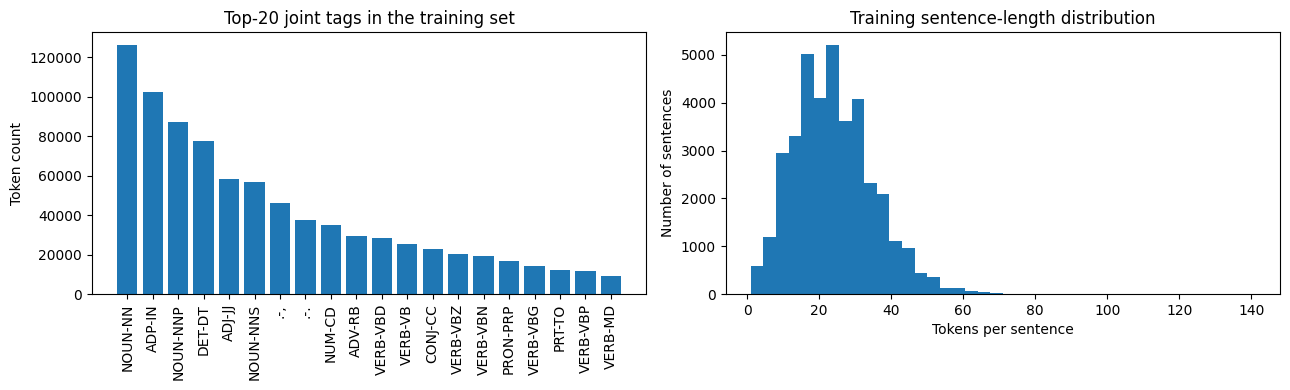

In [3]:
# ---- Data statistics, tag distribution, and sentence lengths ----
from collections import Counter

def split_statistics(name, data):
    split_lengths = [len(s) for s in data]
    split_tags = Counter(t for s in data for t in s.tags)
    return {
        "split": name,
        "sentences": len(data),
        "tokens": int(sum(split_lengths)),
        "mean_length": float(np.mean(split_lengths)),
        "max_length": int(max(split_lengths)),
        "95th_percentile_length": float(np.percentile(split_lengths, 95)),
        "unique_joint_tags": len(split_tags),
    }

data_summary = pd.DataFrame([
    split_statistics("train", train_data),
    split_statistics("dev", dev_data),
])
display(data_summary.round(2))

tag_counts = Counter(t for s in train_data for t in s.tags)
lengths = [len(s) for s in train_data]

print(f"Number of joint tags: {len(tag_counts)}")
print("10 most frequent tags:", tag_counts.most_common(10))
print("10 rarest tags:", tag_counts.most_common()[-10:])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
top = tag_counts.most_common(20)

ax[0].bar([t for t, _ in top], [c for _, c in top])
ax[0].set_title("Top-20 joint tags in the training set")
ax[0].set_ylabel("Token count")
ax[0].tick_params(axis="x", rotation=90)

ax[1].hist(lengths, bins=40)
ax[1].set_title("Training sentence-length distribution")
ax[1].set_xlabel("Tokens per sentence")
ax[1].set_ylabel("Number of sentences")

plt.tight_layout()
plt.show()


**Why this matters.** The distribution is highly skewed — a handful of tags
(`NOUN-NN`, punctuation, `DET-DT`) dominate while many tags are very rare. This is
exactly why **macro-F1** is reported alongside micro-F1: a model can score high
micro-F1 while failing the rare tags entirely. We return to this in §8.

# 6. Experiments

**Evaluation metrics.** For every model and every reported split, we compute:
per-class precision, recall, and F1-score; micro-averaged precision, recall, and
F1-score; macro-averaged precision, recall, and F1-score; and overall
token-level accuracy.

**Baseline.** The classical baseline is a bigram HMM decoded with Viterbi and
add-k smoothing.

**Neural setup.** The neural tagger uses a 100-dimensional word embedding,
50-dimensional Char-CNN output, a BiLSTM hidden size of 256, dropout of 0.5,
embedding dropout of 0.25, Adam with learning rate $10^{-3}$, weight decay of
$10^{-5}$, gradient clipping at 5.0, batch size 32, and early-stopping patience
of 5 epochs. `ReduceLROnPlateau` is used for learning-rate scheduling. The best
checkpoint is selected using development macro-F1.

**Fair comparison and reproducibility.**
- All experiments use the same training/development split and joint-tag mapping.
- Random seed 42 is used throughout.
- Ablations use the same architecture and training hyperparameters except for
  the component intentionally removed.
- No pre-trained embeddings are used in the reported experiments.
- The hidden test set is never used for model selection or intermediate analysis.


## 6.1 Hyperparameter and configuration summary

The following table makes the experimental setup explicit and reproducible.


In [4]:
hyperparameters = pd.DataFrame([
    {"component": "HMM", "parameter": "transition smoothing", "value": "0.01"},
    {"component": "HMM", "parameter": "emission smoothing", "value": "0.01"},
    {"component": "BiLSTM", "parameter": "word embedding dimension", "value": "100"},
    {"component": "BiLSTM", "parameter": "character-CNN output dimension", "value": "50"},
    {"component": "BiLSTM", "parameter": "hidden size", "value": "256"},
    {"component": "BiLSTM", "parameter": "dropout", "value": "0.50"},
    {"component": "BiLSTM", "parameter": "embedding dropout", "value": "0.25"},
    {"component": "Training", "parameter": "optimizer", "value": "Adam"},
    {"component": "Training", "parameter": "learning rate", "value": "0.001"},
    {"component": "Training", "parameter": "weight decay", "value": "0.00001"},
    {"component": "Training", "parameter": "batch size", "value": "32"},
    {"component": "Training", "parameter": "gradient clipping", "value": "5.0"},
    {"component": "Training", "parameter": "maximum epochs", "value": "30"},
    {"component": "Training", "parameter": "early-stopping patience", "value": "5"},
    {"component": "Training", "parameter": "selection metric", "value": "development macro-F1"},
    {"component": "Training", "parameter": "random seed", "value": str(SEED)},
])
display(hyperparameters)


,component,parameter,value
0,HMM,transition smoothing,0.01
1,HMM,emission smoothing,0.01
2,BiLSTM,word embedding dimension,100
3,BiLSTM,character-CNN output dimension,50
4,BiLSTM,hidden size,256
5,BiLSTM,dropout,0.50
6,BiLSTM,embedding dropout,0.25
7,Training,optimizer,Adam
8,Training,learning rate,0.001
9,Training,weight decay,0.00001


In [5]:
# ===== Model 1: HMM + Viterbi =====
hmm = HMMTagger(k_trans=1e-2, k_emit=1e-2).fit(train_data)

def hmm_eval(data, vocab):
    preds = hmm.predict_corpus(data)
    yt, yp = [], []
    for s, ptags in zip(data, preds):
        for gold, pred in zip(s.tags, ptags):
            yt.append(vocab.encode_tag(gold))
            yp.append(vocab.encode_tag(pred))
    return compute_metrics(yt, yp, vocab.idx2tag), (yt, yp)

hmm_train_m, _              = hmm_eval(train_data, vocab)
hmm_dev_m, (hmm_yt, hmm_yp) = hmm_eval(dev_data, vocab)
print("HMM  train:", metrics_summary(hmm_train_m))
print("HMM  dev  :", metrics_summary(hmm_dev_m))

[HMM] fitted: 45 tags, vocab=43357, k_trans=0.01, k_emit=0.01
HMM  train: acc=0.9690  micro-F1=0.9690  macro-F1=0.9048
HMM  dev  : acc=0.9497  micro-F1=0.9497  macro-F1=0.8288


In [6]:
# ===== Model 2: BiLSTM + Char-CNN =====
cfg = ModelConfig(
    n_words=vocab.n_words,
    n_chars=vocab.n_chars,
    n_tags=vocab.n_tags,
    word_emb_dim=100,
    char_cnn_dim=50,
    lstm_hidden=256,
    dropout=0.5,
    emb_dropout=0.25,
    use_char=True,
)

model = BiLSTMTagger(cfg)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
print(f"Trainable neural-model parameters: {trainable_parameters:,}")

tcfg = TrainConfig(
    epochs=30,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-5,
    grad_clip=5.0,
    patience=5,
    seed=SEED,
)

model, history = train_model(
    model,
    train_data,
    dev_data,
    vocab,
    tcfg,
    DEVICE,
)


Trainable neural-model parameters: 3,175,669
epoch 01  loss=0.4683  dev acc=0.9535  micro-F1=0.9535  macro-F1=0.8121
epoch 02  loss=0.1530  dev acc=0.9662  micro-F1=0.9662  macro-F1=0.8526
epoch 03  loss=0.1157  dev acc=0.9703  micro-F1=0.9703  macro-F1=0.8594
epoch 04  loss=0.1000  dev acc=0.9712  micro-F1=0.9712  macro-F1=0.8575
epoch 05  loss=0.0915  dev acc=0.9718  micro-F1=0.9718  macro-F1=0.8570
epoch 06  loss=0.0863  dev acc=0.9727  micro-F1=0.9727  macro-F1=0.8543
epoch 07  loss=0.0760  dev acc=0.9733  micro-F1=0.9733  macro-F1=0.8602
epoch 08  loss=0.0733  dev acc=0.9737  micro-F1=0.9737  macro-F1=0.8604
epoch 09  loss=0.0717  dev acc=0.9736  micro-F1=0.9736  macro-F1=0.8578
epoch 10  loss=0.0699  dev acc=0.9743  micro-F1=0.9743  macro-F1=0.8649
epoch 11  loss=0.0680  dev acc=0.9737  micro-F1=0.9737  macro-F1=0.8631
epoch 12  loss=0.0667  dev acc=0.9736  micro-F1=0.9736  macro-F1=0.8570
epoch 13  loss=0.0651  dev acc=0.9737  micro-F1=0.9737  macro-F1=0.8624
epoch 14  loss=0.05

In [7]:
# ---- Final train/dev evaluation for the neural model ----
bl_train_m, _ = evaluate(model, train_data, vocab, DEVICE)
bl_dev_m, (bl_yt, bl_yp) = evaluate(model, dev_data, vocab, DEVICE)

print("BiLSTM train:", metrics_summary(bl_train_m))
print("BiLSTM dev  :", metrics_summary(bl_dev_m))

# Independent cross-check against scikit-learn.
print(
    "scikit-learn cross-check (dev):",
    sklearn_crosscheck(bl_yt, bl_yp, vocab.idx2tag),
)

# Reproducibility and integrity sanity checks.
expected_dev_tokens = sum(len(sentence) for sentence in dev_data)

assert len(bl_yt) == expected_dev_tokens
assert len(bl_yp) == expected_dev_tokens
assert len(hmm_yt) == expected_dev_tokens
assert len(hmm_yp) == expected_dev_tokens

assert all(0 <= tag_id < vocab.n_tags for tag_id in bl_yt)
assert all(0 <= tag_id < vocab.n_tags for tag_id in bl_yp)
assert all(0 <= tag_id < vocab.n_tags for tag_id in hmm_yt)
assert all(0 <= tag_id < vocab.n_tags for tag_id in hmm_yp)

print(f"Sanity checks passed for {expected_dev_tokens:,} development tokens.")


BiLSTM train: acc=0.9824  micro-F1=0.9824  macro-F1=0.9205
BiLSTM dev  : acc=0.9743  micro-F1=0.9743  macro-F1=0.8649
scikit-learn cross-check (dev): {'accuracy': 0.9743241522726308, 'micro_f1': 0.9743241522726308, 'macro_f1': 0.8649411227886341}
Sanity checks passed for 47,126 development tokens.


# 7. Results

## 7.1 Headline comparison (train vs dev, both models)

In [8]:
def overall_metrics_row(model_name, split_name, metrics):
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": metrics["accuracy"],
        "micro_precision": metrics["micro"]["precision"],
        "micro_recall": metrics["micro"]["recall"],
        "micro_f1": metrics["micro"]["f1"],
        "macro_precision": metrics["macro"]["precision"],
        "macro_recall": metrics["macro"]["recall"],
        "macro_f1": metrics["macro"]["f1"],
    }

complete_summary = pd.DataFrame([
    overall_metrics_row("HMM", "train", hmm_train_m),
    overall_metrics_row("HMM", "dev", hmm_dev_m),
    overall_metrics_row("BiLSTM + Char-CNN", "train", bl_train_m),
    overall_metrics_row("BiLSTM + Char-CNN", "dev", bl_dev_m),
])

complete_summary["error_rate"] = 1.0 - complete_summary["accuracy"]
display(complete_summary.round(4))

generalization_rows = []
for model_name in complete_summary["model"].unique():
    model_rows = complete_summary[complete_summary["model"] == model_name]
    train_row = model_rows[model_rows["split"] == "train"].iloc[0]
    dev_row = model_rows[model_rows["split"] == "dev"].iloc[0]

    generalization_rows.append({
        "model": model_name,
        "train_accuracy": train_row["accuracy"],
        "dev_accuracy": dev_row["accuracy"],
        "accuracy_gap": train_row["accuracy"] - dev_row["accuracy"],
        "train_macro_f1": train_row["macro_f1"],
        "dev_macro_f1": dev_row["macro_f1"],
        "macro_f1_gap": train_row["macro_f1"] - dev_row["macro_f1"],
    })

generalization_table = pd.DataFrame(generalization_rows)
display(generalization_table.round(4))

hmm_dev_error = 1.0 - hmm_dev_m["accuracy"]
bilstm_dev_error = 1.0 - bl_dev_m["accuracy"]
relative_error_reduction = (
    (hmm_dev_error - bilstm_dev_error) / hmm_dev_error
)

print(
    "Relative development error reduction of BiLSTM + Char-CNN over HMM: "
    f"{relative_error_reduction:.2%}"
)


,model,split,accuracy,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,error_rate
0,HMM,train,0.9690,0.9690,0.9690,0.9690,0.8917,0.9240,0.9048,0.0310
1,HMM,dev,0.9497,0.9497,0.9497,0.9497,0.7985,0.8947,0.8288,0.0503
2,BiLSTM + Char-CNN,train,0.9824,0.9824,0.9824,0.9824,0.9341,0.9136,0.9205,0.0176
3,BiLSTM + Char-CNN,dev,0.9743,0.9743,0.9743,0.9743,0.8610,0.8717,0.8649,0.0257


,model,train_accuracy,dev_accuracy,accuracy_gap,train_macro_f1,dev_macro_f1,macro_f1_gap
0,HMM,0.9690,0.9497,0.0192,0.9048,0.8288,0.0759
1,BiLSTM + Char-CNN,0.9824,0.9743,0.0081,0.9205,0.8649,0.0555


Relative development error reduction of BiLSTM + Char-CNN over HMM: 48.92%


## 7.2 Per-class metrics — every tag, both models, both splits

The next cell reports precision, recall, F1-score, and support for every joint
POS tag on the training and development sets for both models. This directly
satisfies the required per-class reporting requirement.


In [9]:
metric_sets = [
    ("HMM", "train", hmm_train_m),
    ("HMM", "dev", hmm_dev_m),
    ("BiLSTM + Char-CNN", "train", bl_train_m),
    ("BiLSTM + Char-CNN", "dev", bl_dev_m),
]

per_class_frames = []

for model_name, split_name, metrics in metric_sets:
    class_table = per_class_table(metrics, sort_by_support=True).copy()
    class_table.insert(0, "split", split_name)
    class_table.insert(0, "model", model_name)
    per_class_frames.append(class_table)

    print("=" * 88)
    print(f"{model_name} — {split_name}")
    print("=" * 88)
    display(class_table.round(4))

all_per_class = pd.concat(per_class_frames, ignore_index=True)

# Keep the BiLSTM development table for the detailed plots below.
pc = per_class_table(bl_dev_m, sort_by_support=True)


HMM — train


,model,split,tag,precision,recall,f1,support
0,HMM,train,NOUN-NN,0.9768,0.9629,0.9698,126176
1,HMM,train,ADP-IN,0.9775,0.9784,0.9780,102515
2,HMM,train,NOUN-NNP,0.9692,0.9773,0.9732,87033
3,HMM,train,DET-DT,0.9941,0.9881,0.9911,77723
4,HMM,train,ADJ-JJ,0.9231,0.9479,0.9353,58227
5,HMM,train,NOUN-NNS,0.9820,0.9829,0.9824,56900
6,HMM,train,".-,",0.9999,0.9999,0.9999,46317
7,HMM,train,.-.,0.9979,0.9999,0.9989,37506
8,HMM,train,NUM-CD,0.9967,0.9913,0.9940,34775
9,HMM,train,ADV-RB,0.9196,0.8935,0.9064,29382


HMM — dev


,model,split,tag,precision,recall,f1,support
0,HMM,dev,NOUN-NN,0.9713,0.9379,0.9543,6759
1,HMM,dev,ADP-IN,0.9755,0.9757,0.9756,5347
2,HMM,dev,NOUN-NNP,0.9560,0.9366,0.9462,4433
3,HMM,dev,DET-DT,0.9922,0.9854,0.9888,4109
4,HMM,dev,ADJ-JJ,0.9068,0.8983,0.9026,2990
5,HMM,dev,NOUN-NNS,0.9620,0.9503,0.9561,2956
6,HMM,dev,".-,",0.9967,1.0000,0.9983,2410
7,HMM,dev,.-.,0.9965,0.9995,0.9980,1972
8,HMM,dev,NUM-CD,0.9862,0.9576,0.9717,1793
9,HMM,dev,ADV-RB,0.9113,0.8860,0.8985,1588


BiLSTM + Char-CNN — train


,model,split,tag,precision,recall,f1,support
0,BiLSTM + Char-CNN,train,NOUN-NN,0.9830,0.9760,0.9795,126176
1,BiLSTM + Char-CNN,train,ADP-IN,0.9886,0.9895,0.9891,102515
2,BiLSTM + Char-CNN,train,NOUN-NNP,0.9830,0.9841,0.9835,87033
3,BiLSTM + Char-CNN,train,DET-DT,0.9955,0.9967,0.9961,77723
4,BiLSTM + Char-CNN,train,ADJ-JJ,0.9464,0.9577,0.9520,58227
5,BiLSTM + Char-CNN,train,NOUN-NNS,0.9899,0.9920,0.9909,56900
6,BiLSTM + Char-CNN,train,".-,",1.0000,0.9999,1.0000,46317
7,BiLSTM + Char-CNN,train,.-.,0.9999,1.0000,0.9999,37506
8,BiLSTM + Char-CNN,train,NUM-CD,0.9925,0.9968,0.9947,34775
9,BiLSTM + Char-CNN,train,ADV-RB,0.9508,0.9385,0.9446,29382


BiLSTM + Char-CNN — dev


,model,split,tag,precision,recall,f1,support
0,BiLSTM + Char-CNN,dev,NOUN-NN,0.9739,0.9612,0.9675,6759
1,BiLSTM + Char-CNN,dev,ADP-IN,0.9848,0.9837,0.9843,5347
2,BiLSTM + Char-CNN,dev,NOUN-NNP,0.9734,0.9808,0.9771,4433
3,BiLSTM + Char-CNN,dev,DET-DT,0.9951,0.9932,0.9942,4109
4,BiLSTM + Char-CNN,dev,ADJ-JJ,0.9164,0.9428,0.9294,2990
5,BiLSTM + Char-CNN,dev,NOUN-NNS,0.9814,0.9831,0.9823,2956
6,BiLSTM + Char-CNN,dev,".-,",1.0000,1.0000,1.0000,2410
7,BiLSTM + Char-CNN,dev,.-.,1.0000,1.0000,1.0000,1972
8,BiLSTM + Char-CNN,dev,NUM-CD,0.9933,0.9927,0.9930,1793
9,BiLSTM + Char-CNN,dev,ADV-RB,0.9394,0.9276,0.9335,1588


## 7.3 Per-class precision/recall/F1 heatmap


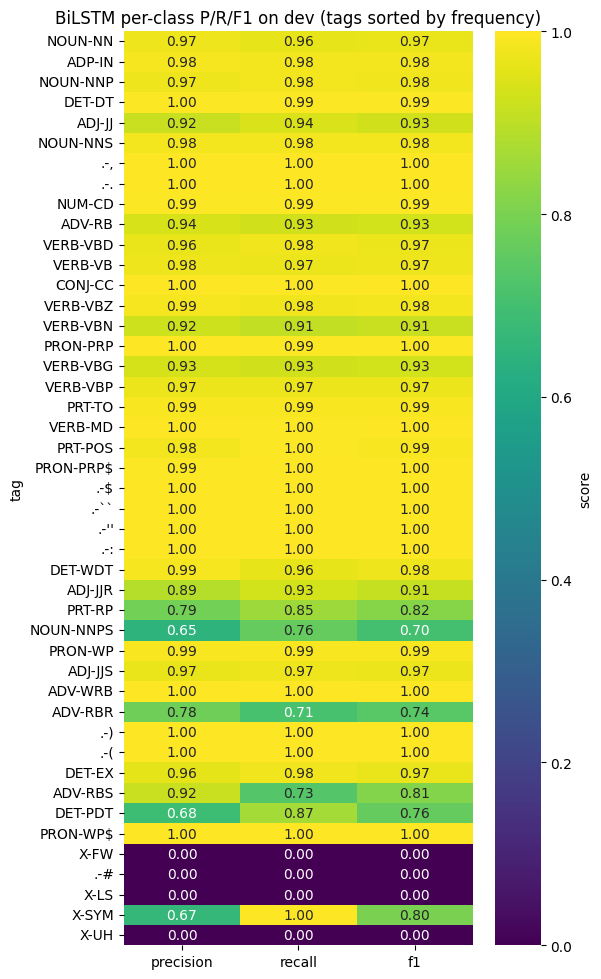

In [10]:
pc_sorted = pc.sort_values("support", ascending=False)
plt.figure(figsize=(6, max(6, len(pc_sorted)*0.22)))
sns.heatmap(pc_sorted.set_index("tag")[["precision","recall","f1"]],
            annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label":"score"})
plt.title("BiLSTM per-class P/R/F1 on dev (tags sorted by frequency)")
plt.tight_layout(); plt.show()

## 7.4 Performance by tag-frequency band

To make the frequent-versus-rare gap measurable, tags are grouped by their
development-set support. These thresholds are descriptive analysis choices,
not additional training hyperparameters.


,frequency_band,number_of_tags,total_tokens,mean_precision,mean_recall,mean_f1
0,very rare (<10),6,25,0.2778,0.3333,0.3000
1,rare (10-49),3,77,0.8531,0.8596,0.8493
2,medium (50-499),17,3772,0.9423,0.9514,0.9464
3,frequent (>=500),19,43252,0.9736,0.9723,0.9729


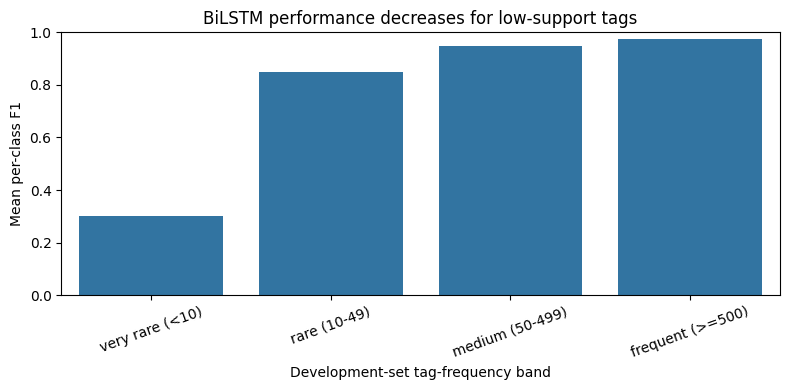

In [11]:
def frequency_band(support):
    if support < 10:
        return "very rare (<10)"
    if support < 50:
        return "rare (10-49)"
    if support < 500:
        return "medium (50-499)"
    return "frequent (>=500)"

band_order = [
    "very rare (<10)",
    "rare (10-49)",
    "medium (50-499)",
    "frequent (>=500)",
]

pc_bands = pc.copy()
pc_bands["frequency_band"] = pc_bands["support"].apply(frequency_band)

band_summary = (
    pc_bands.groupby("frequency_band", observed=False)
    .agg(
        number_of_tags=("tag", "count"),
        total_tokens=("support", "sum"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
    )
    .reindex(band_order)
    .reset_index()
)

display(band_summary.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=band_summary, x="frequency_band", y="mean_f1")
plt.ylim(0, 1)
plt.xlabel("Development-set tag-frequency band")
plt.ylabel("Mean per-class F1")
plt.title("BiLSTM performance decreases for low-support tags")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7.5 Learning curves


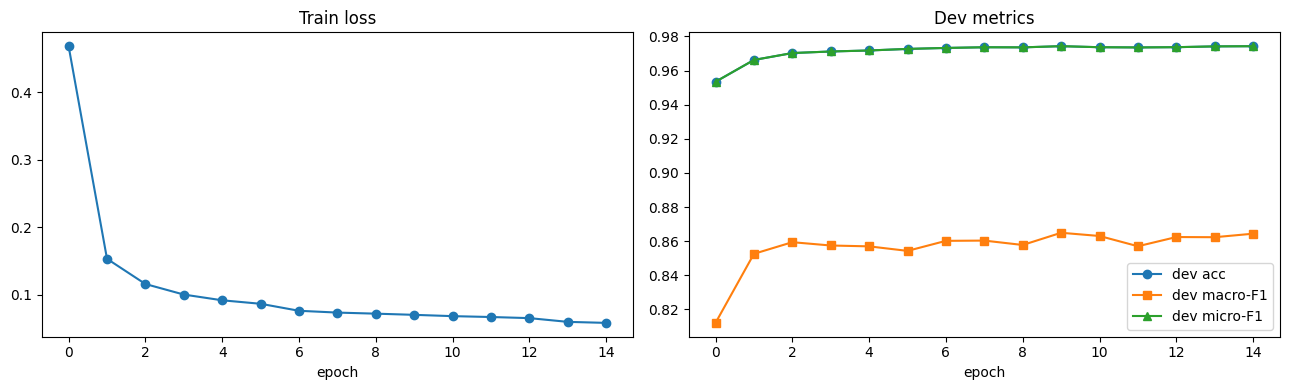

In [12]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].plot(history["train_loss"], marker="o"); ax[0].set_title("Train loss")
ax[0].set_xlabel("epoch")
ax[1].plot(history["dev_acc"], label="dev acc", marker="o")
ax[1].plot(history["dev_macro_f1"], label="dev macro-F1", marker="s")
ax[1].plot(history["dev_micro_f1"], label="dev micro-F1", marker="^")
ax[1].set_title("Dev metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7.6 Normalized confusion matrix for the most frequent tags

The full 45×45 matrix is difficult to read in a report, so this visualization
shows the 15 tags with the largest gold support. Each row is normalized by the
total number of gold examples for that tag. Errors outside the displayed
15-tag subset still contribute to the row normalization.


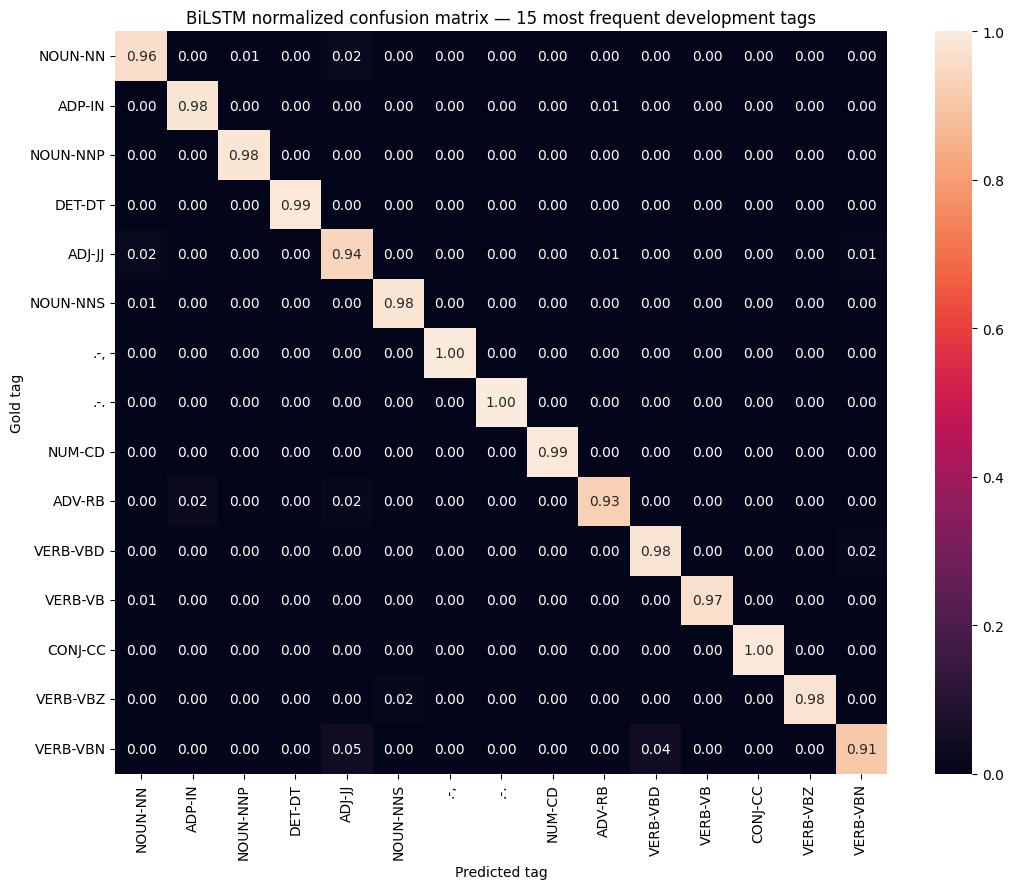

In [13]:
top_k = 15
n_tags = vocab.n_tags

confusion = np.zeros((n_tags, n_tags), dtype=np.int64)
for gold_id, predicted_id in zip(bl_yt, bl_yp):
    confusion[gold_id, predicted_id] += 1

gold_support = confusion.sum(axis=1)
top_tag_ids = np.argsort(gold_support)[::-1][:top_k]

normalized_confusion = np.divide(
    confusion,
    gold_support[:, None],
    out=np.zeros_like(confusion, dtype=float),
    where=gold_support[:, None] != 0,
)

top_confusion = normalized_confusion[np.ix_(top_tag_ids, top_tag_ids)]
top_labels = [vocab.idx2tag[tag_id] for tag_id in top_tag_ids]

plt.figure(figsize=(11, 9))
sns.heatmap(
    pd.DataFrame(top_confusion, index=top_labels, columns=top_labels),
    annot=True,
    fmt=".2f",
)
plt.xlabel("Predicted tag")
plt.ylabel("Gold tag")
plt.title("BiLSTM normalized confusion matrix — 15 most frequent development tags")
plt.tight_layout()
plt.show()


## 7.7 Controlled ablation study

The neural model is retrained after removing one component at a time:
`no_char` removes the character-level encoder, and `no_dropout` disables both
standard and embedding dropout. Every other architecture and training setting is
kept identical to the full model. This cell is computationally expensive because
it trains two additional models.


In [14]:
def quick_ablation(name, **overrides):
    set_seed(SEED)

    model_settings = {
        "word_emb_dim": 100,
        "char_cnn_dim": 50,
        "lstm_hidden": 256,
        "dropout": 0.5,
        "emb_dropout": 0.25,
        "use_char": True,
    }
    model_settings.update(overrides)

    ablation_config = ModelConfig(
        n_words=vocab.n_words,
        n_chars=vocab.n_chars,
        n_tags=vocab.n_tags,
        **model_settings,
    )

    ablation_model = BiLSTMTagger(ablation_config)

    # Use the same training settings as the full model for a controlled comparison.
    ablation_train_config = TrainConfig(
        epochs=30,
        batch_size=32,
        lr=1e-3,
        weight_decay=1e-5,
        grad_clip=5.0,
        patience=5,
        seed=SEED,
    )

    ablation_model, _ = train_model(
        ablation_model,
        train_data,
        dev_data,
        vocab,
        ablation_train_config,
        DEVICE,
    )

    result, _ = evaluate(ablation_model, dev_data, vocab, DEVICE)

    return {
        "config": name,
        "accuracy": result["accuracy"],
        "micro_f1": result["micro"]["f1"],
        "macro_f1": result["macro"]["f1"],
    }

abl = pd.DataFrame([
    {
        "config": "full (char + dropout)",
        "accuracy": bl_dev_m["accuracy"],
        "micro_f1": bl_dev_m["micro"]["f1"],
        "macro_f1": bl_dev_m["macro"]["f1"],
    },
    quick_ablation(
        "no_char",
        use_char=False,
    ),
    quick_ablation(
        "no_dropout",
        dropout=0.0,
        emb_dropout=0.0,
    ),
])

full_accuracy = abl.loc[abl["config"] == "full (char + dropout)", "accuracy"].iloc[0]
full_macro_f1 = abl.loc[abl["config"] == "full (char + dropout)", "macro_f1"].iloc[0]

abl["delta_accuracy_vs_full"] = abl["accuracy"] - full_accuracy
abl["delta_macro_f1_vs_full"] = abl["macro_f1"] - full_macro_f1

display(abl.round(4))


epoch 01  loss=0.7664  dev acc=0.8999  micro-F1=0.8999  macro-F1=0.7712
epoch 02  loss=0.2909  dev acc=0.9470  micro-F1=0.9470  macro-F1=0.8195
epoch 03  loss=0.1798  dev acc=0.9570  micro-F1=0.9570  macro-F1=0.8402
epoch 04  loss=0.1390  dev acc=0.9625  micro-F1=0.9625  macro-F1=0.8570
epoch 05  loss=0.1205  dev acc=0.9634  micro-F1=0.9634  macro-F1=0.8508
epoch 06  loss=0.1111  dev acc=0.9640  micro-F1=0.9640  macro-F1=0.8514
epoch 07  loss=0.1041  dev acc=0.9641  micro-F1=0.9641  macro-F1=0.8578
epoch 08  loss=0.0998  dev acc=0.9650  micro-F1=0.9650  macro-F1=0.8555
epoch 09  loss=0.0955  dev acc=0.9648  micro-F1=0.9648  macro-F1=0.8613
epoch 10  loss=0.0919  dev acc=0.9646  micro-F1=0.9646  macro-F1=0.8557
epoch 11  loss=0.0883  dev acc=0.9648  micro-F1=0.9648  macro-F1=0.8574
epoch 12  loss=0.0862  dev acc=0.9645  micro-F1=0.9645  macro-F1=0.8566
epoch 13  loss=0.0749  dev acc=0.9664  micro-F1=0.9664  macro-F1=0.8656
epoch 14  loss=0.0726  dev acc=0.9663  micro-F1=0.9663  macro-F1

,config,accuracy,micro_f1,macro_f1,delta_accuracy_vs_full,delta_macro_f1_vs_full
0,full (char + dropout),0.9743,0.9743,0.8649,0.0000,0.0000
1,no_char,0.9656,0.9656,0.8673,-0.0087,0.0024
2,no_dropout,0.9701,0.9701,0.8663,-0.0042,0.0014


# 8. Analysis & Conclusion

## 8.1 Frequent versus rare tags
The complete per-class tables, heatmap, and frequency-band analysis show a clear
class-imbalance effect. High-support tags such as `NOUN-NN`, `ADP-IN`, `DET-DT`,
and punctuation achieve very high F1-scores. Several extremely rare
development-set tags, including `X-FW`, `X-LS`, and `X-UH`, receive an F1-score
of zero in the recorded run. Because macro-F1 gives every class equal weight,
these failures reduce macro-F1 even when token accuracy and micro-F1 remain
high.

The frequency-band table makes this effect explicit: mean per-class F1 is much
less stable for tags with only a handful of development examples. Results for
those classes should therefore be interpreted together with their support.


In [15]:
# Top confusion pairs (gold -> predicted) for the neural model on dev
pairs = confusion_pairs(bl_yt, bl_yp, vocab.idx2tag, top_k=15)
pd.DataFrame([{"gold":g,"predicted":p,"count":c} for (g,p),c in pairs])

,gold,predicted,count
0,NOUN-NN,ADJ-JJ,140
1,ADJ-JJ,NOUN-NN,64
2,NOUN-NN,NOUN-NNP,58
3,ADP-IN,ADV-RB,45
4,VERB-VBG,NOUN-NN,44
5,VERB-VBN,ADJ-JJ,44
6,ADJ-JJ,VERB-VBN,43
7,NOUN-NNP,NOUN-NNPS,43
8,VERB-VBN,VERB-VBD,42
9,ADV-RB,ADP-IN,38


**Reading the confusions.** The largest errors are between linguistically
related or contextually ambiguous categories. Important examples include
`NOUN-NN` versus `ADJ-JJ`, `NOUN-NN` versus `NOUN-NNP`, `ADP-IN` versus
`ADV-RB`, and `VERB-VBD` versus `VERB-VBN`. These errors are plausible because
the correct tag can depend on sentence context rather than the word form alone.

## 8.2 HMM versus BiLSTM + Char-CNN
In the recorded run, the HMM obtains **94.97% development accuracy** and
**0.8288 macro-F1**, while the BiLSTM + Char-CNN obtains **97.43% development
accuracy** and **0.8649 macro-F1**. The neural model benefits from bidirectional
context and learned word and character representations. The HMM is limited to
bigram tag transitions and word-level emission counts, which makes unknown and
ambiguous words harder to resolve.

The complete metrics table also reports train-to-development gaps and the
relative reduction in development error, making it possible to compare both
predictive quality and generalization.

## 8.3 Ablation interpretation
The controlled ablation table should be interpreted using both accuracy and
macro-F1. A negative `delta_accuracy_vs_full` means that removing the component
reduced overall token accuracy. A positive `delta_macro_f1_vs_full` means that
the ablated run happened to score slightly better on the unweighted class
average. Because several classes have extremely low support and only one random
seed is reported, small macro-F1 differences should not be treated as strong
evidence. The most defensible conclusion is based on the complete table rather
than on one metric alone.

## 8.4 Limitations and future work
- The main experiments use one fixed random seed. Multiple independent runs
  would provide confidence intervals and a more reliable comparison of small
  macro-F1 differences.
- A CRF output layer could explicitly model dependencies between neighbouring
  tags.
- The joint coarse–fine tag set creates a large and imbalanced label space. A
  factored coarse/fine prediction objective could be explored.
- Additional controlled experiments could evaluate pre-trained embeddings or a
  small hyperparameter search.
- The held-out test set is unavailable to the team and will be evaluated by the
  instructor.

## 8.5 Conclusion
Two distinct POS-tagging approaches were implemented and evaluated on the same
joint-tag task. The BiLSTM + Char-CNN clearly outperforms the HMM on development
accuracy and macro-F1. Complete train/development metrics, per-class results,
learning curves, a normalized confusion matrix, frequency-band analysis, and
controlled ablations provide a fuller picture than accuracy alone. The main
remaining weakness is performance instability on very rare tags.


# 9. AI Usage Statement

AI-assisted tools were used during this project as supplementary support resources. These tools helped explain programming errors and debugging messages, clarify Python and PyTorch syntax and library usage, suggest improvements to notebook organization and code readability, and assist in refining the language and structure of documentation and Markdown sections. AI assistance was also used to generate ideas for data visualization, reporting formats, confusion-matrix presentation, frequency-based error analysis, and the organization of experimental and ablation-study results.

The AI tools served only as guidance and productivity aids and were not used to independently design, implement, or validate the project. The complete data-processing pipeline, HMM/Viterbi implementation, BiLSTM + Char-CNN model development, training procedures, experiment execution, result analysis, and final conclusions were designed, implemented, tested, and verified by the project team. All AI-generated suggestions were critically reviewed, modified when necessary, experimentally validated, and approved by the team before inclusion. The team assumes full responsibility for all submitted code, results, interpretations, and references.

# 10. References

1. X. Ma and E. Hovy. “End-to-end Sequence Labeling via Bi-directional
   LSTM-CNNs-CRF.” *Proceedings of ACL*, 2016.
2. K. Toutanova, D. Klein, C. D. Manning, and Y. Singer. “Feature-Rich
   Part-of-Speech Tagging with a Cyclic Dependency Network.” *Proceedings of
   HLT-NAACL*, 2003.
3. A. Ratnaparkhi. “A Maximum Entropy Model for Part-of-Speech Tagging.”
   *Proceedings of EMNLP*, 1996.
4. J. Kupiec. “Robust Part-of-Speech Tagging Using a Hidden Markov Model.”
   *Computer Speech & Language*, 6(3), 1992.
5. A. Paszke et al. “PyTorch: An Imperative Style, High-Performance Deep
   Learning Library.” *Advances in Neural Information Processing Systems*,
   2019.
6. F. Pedregosa et al. “Scikit-learn: Machine Learning in Python.”
   *Journal of Machine Learning Research*, 12, 2011.
7. C. R. Harris et al. “Array Programming with NumPy.” *Nature*, 585, 2020.
8. W. McKinney. “Data Structures for Statistical Computing in Python.”
   *Proceedings of the 9th Python in Science Conference*, 2010.
9. J. D. Hunter. “Matplotlib: A 2D Graphics Environment.”
   *Computing in Science & Engineering*, 9(3), 2007.
10. M. L. Waskom. “Seaborn: Statistical Data Visualization.”
    *Journal of Open Source Software*, 6(60), 2021.
11. ENCS5342 Final Course Project specification and the course-provided English
    Penn Treebank data in Stanford-style CoNLL format, Birzeit University, 2026.
